In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_cert = pd.read_csv('../data/certidoes_negativas_funai_v5.csv')
df_rep = pd.read_csv('../data/reportagens_certidoes_negativas.csv', sep=';')

print("Certidões:", df_cert.shape)
print("Reportagens:", df_rep.shape)

Certidões: (78, 34)
Reportagens: (105, 14)


In [72]:
# Visão geral das certidões
df_cert.info()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Nº do Processo             77 non-null     str    
 1   Empresa / Requerente       75 non-null     str    
 2   Data do Requerimento       77 non-null     str    
 3   Origem (FUNAI)             78 non-null     str    
 4   Tem Certidão Negativa?     78 non-null     str    
 5   Nome do Responsável        76 non-null     str    
 6   Nº da Certidão             49 non-null     str    
 7   Data da Certidão           78 non-null     str    
 8   Nome do Signatário         78 non-null     str    
 9   Cargo do Signatário        78 non-null     str    
 10  UF Empresa                 77 non-null     str    
 11  UF da Área                 78 non-null     str    
 12  Município                  78 non-null     str    
 13  Tamanho da Área (ha)       52 non-null     float64
 14  Coorden

In [73]:
# Ver os primeiros valores da coluna
print(df_cert['Povos ou TIs Mencionados'].dropna().head(10))

0                          Parque Indígena do Araguaia
1                                 Área Indígena Cateté
2                            A.I. TROCARÁ; A.I. ANAMBÉ
3    PARQUE INDÍGENA DO ARAGUAIA; ÁREA IND. KARAJA ...
4                      Uru-Eu-Wau-Wau; Igarapé Lourdes
5                                 Área Indígena Areões
6    Área Indígena Escondido; Área Indígena Rikbakt...
7    Tenharim/Transamazônica; Tenharim/Igarapé Pret...
8                      Bakairi (Área Indígena Santana)
9               Tembé; Reserva Indígena Alto Rio Guamá
Name: Povos ou TIs Mencionados, dtype: str


In [74]:
# Explodir a coluna de povos
povos = (df_cert['Povos ou TIs Mencionados']
         .dropna()
         .str.split(';')
         .explode()
         .str.strip()
         .str.title())

# Contar frequências
contagem_povos = povos.value_counts()
print(contagem_povos)

Povos ou TIs Mencionados
Kayapó                           8
Xavante                          5
Karajá                           3
Parque Indígena Kaiapó           3
Parque Indígena Do Araguaia      2
                                ..
Anambé                           1
Área Indígena Kayapó             1
Rikaktsa-Japuira                 1
Área Indígena Marechal Rondon    1
Área Indígena Parabubure         1
Name: count, Length: 72, dtype: int64


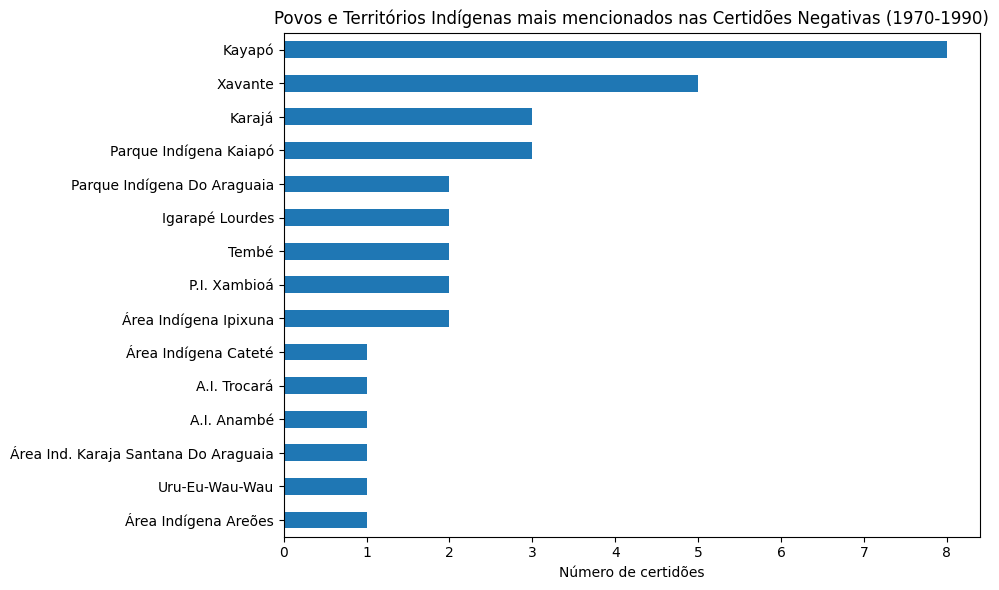

In [75]:
# Gráfico dos 15 povos mais mencionados
plt.figure(figsize=(10, 6))
contagem_povos.head(15).plot(kind='barh')
plt.title('Povos e Territórios Indígenas mais mencionados nas Certidões Negativas (1970-1990)')
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/01_povos_certidoes.png', dpi=300)
plt.show()

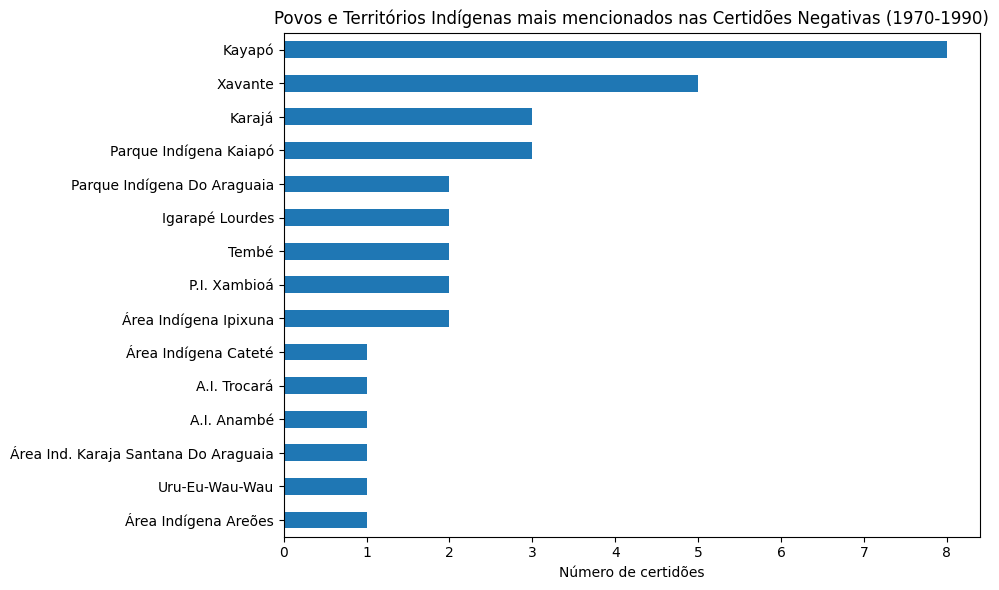

In [76]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

# Gráfico dos 15 povos mais mencionados
plt.figure(figsize=(10, 6))
contagem_povos.head(15).plot(kind='barh')
plt.title('Povos e Territórios Indígenas mais mencionados nas Certidões Negativas (1970-1990)')
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/01_povos_certidoes.png', dpi=300)
plt.show()

In [77]:
df_cert = pd.read_csv('../data/certidoes_negativas_funai_v6.csv')
print("Shape:", df_cert.shape)
print("\nColunas novas:")
print([col for col in df_cert.columns if col in ['Povos_Mencionados', 'TIs_Mencionadas', 'Povos_Afetados']])

Shape: (78, 26)

Colunas novas:
[]


In [78]:
print(list(df_cert.columns))

['Nº do Processo', 'Empresa / Requerente', 'Data do Requerimento', 'Origem (FUNAI)', 'Tem Certidão Negativa?', 'Nome do Responsável', 'Nº da Certidão', 'Data da Certidão', 'Nome do Signatário', 'Cargo do Signatário', 'UF Empresa', 'UF da Área', 'Município', 'Tamanho da Área (ha)', 'Coordenadas Geográficas', 'Tem Mapas?', 'Total de Mapas', 'Tem Doc. de Deferimento?', 'Quem Assina o Deferimento', 'Departamento', 'Quem Foi Consultado?', 'Povos Indígenas Mencionados', 'TIs Mencionadas (em parêntesis nome atual)', 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)', 'Observações', 'Referência (arquivo)']


In [79]:
for i, col in enumerate(df_cert.columns):
    print(i, col)

0 Nº do Processo
1 Empresa / Requerente
2 Data do Requerimento
3 Origem (FUNAI)
4 Tem Certidão Negativa?
5 Nome do Responsável
6 Nº da Certidão
7 Data da Certidão
8 Nome do Signatário
9 Cargo do Signatário
10 UF Empresa
11 UF da Área
12 Município
13 Tamanho da Área (ha)
14 Coordenadas Geográficas
15 Tem Mapas?
16 Total de Mapas
17 Tem Doc. de Deferimento?
18 Quem Assina o Deferimento
19 Departamento
20 Quem Foi Consultado?
21 Povos Indígenas Mencionados
22 TIs Mencionadas (em parêntesis nome atual)
23 Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)
24 Observações
25 Referência (arquivo)


In [80]:
# Explodir a coluna Povos Possivelmente Afetados
col_afetados = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'

povos_afetados = (df_cert[col_afetados]
                  .dropna()
                  .str.split(';')
                  .explode()
                  .str.strip()
                  .str.title())

contagem_afetados = povos_afetados.value_counts()
print(contagem_afetados)

Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)
Kayapó                              14
Xavante                              8
Asurini                              5
Isolados Do Rio Fresco               5
Guarani                              4
Karajá                               3
Parintintin                          3
Apyãwa                               2
Avá-Canoeiro                         2
Iny Karajá                           2
Javaé                                2
Xikrin                               2
Anambé                               2
Rikbaktsa                            2
Bakairi                              2
Tembé                                2
Awa Guajá                            2
Ka'Apor                              2
Aweti                                2
Ikpeng                               2
Kajkwakratxi (Tapayuna)              2
Kalapalo                             2
Kamaiurá                             2
Kawaiwete (Kaia

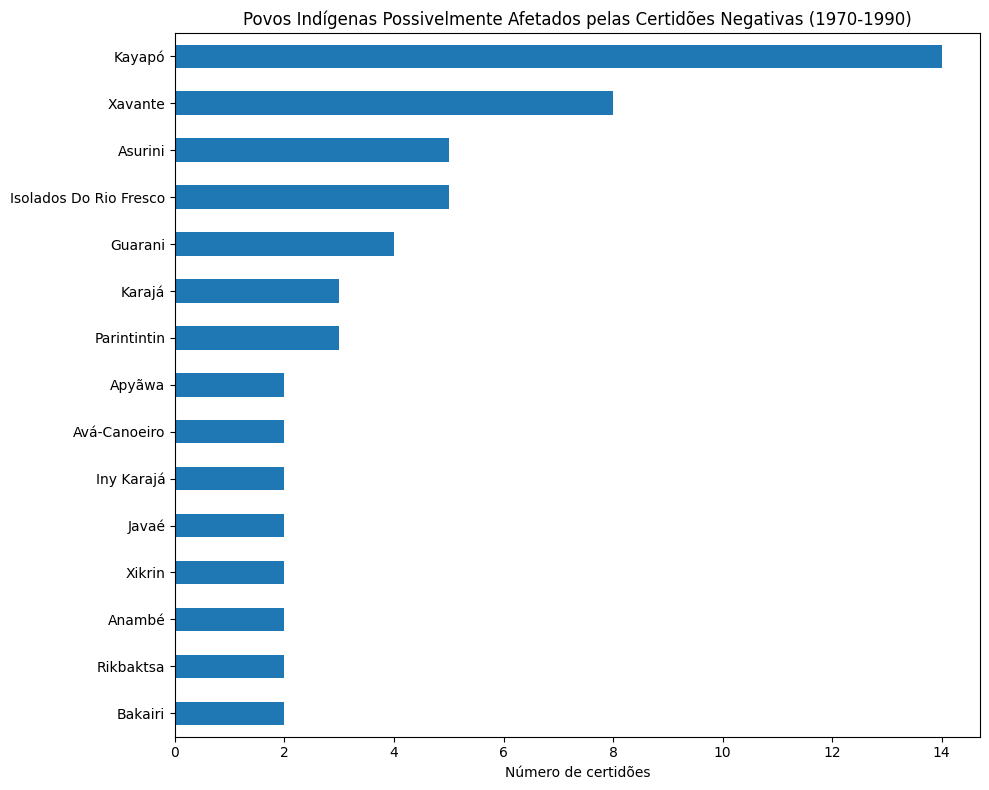

In [81]:
os.makedirs('../outputs/figures', exist_ok=True)

plt.figure(figsize=(10, 8))
contagem_afetados.head(15).plot(kind='barh')
plt.title('Povos Indígenas Possivelmente Afetados pelas Certidões Negativas (1970-1990)')
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/02_povos_afetados.png', dpi=300)
plt.show()

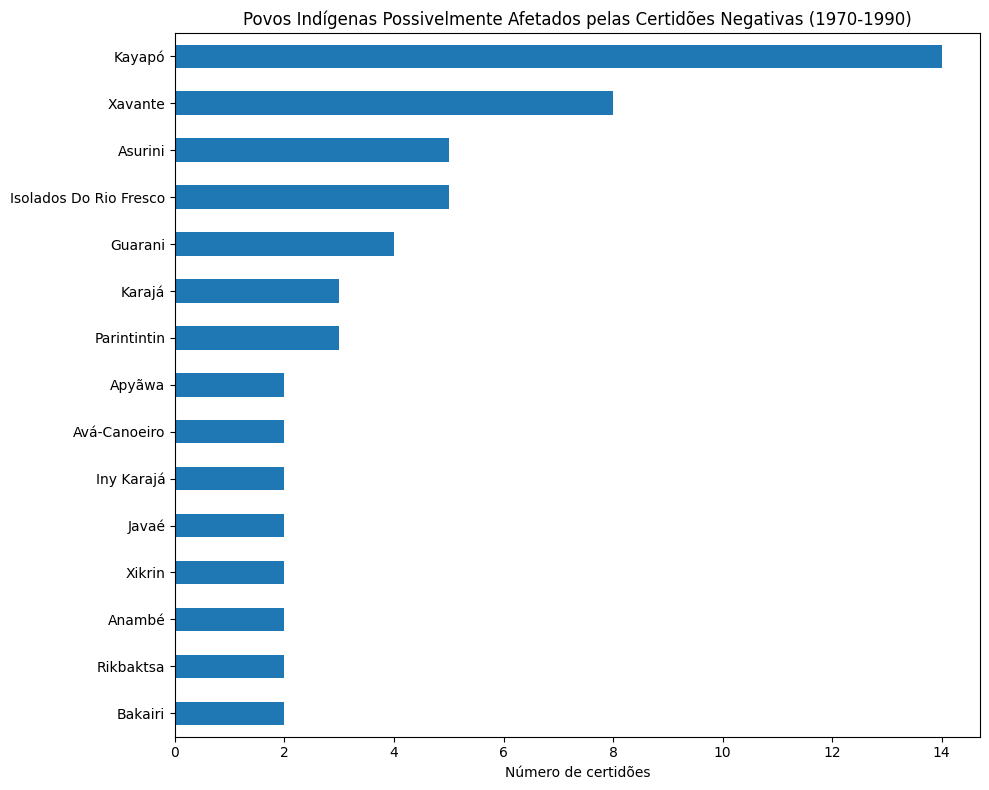

In [82]:
os.makedirs('../outputs/figures', exist_ok=True)

plt.figure(figsize=(10, 8))
contagem_afetados.head(15).plot(kind='barh')
plt.title('Povos Indígenas Possivelmente Afetados pelas Certidões Negativas (1970-1990)')
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/02_povos_afetados.png', dpi=300)
plt.show()

In [83]:
col_afetados = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'

# Encontrar todas as entradas que contêm "Asurini"
asurini = df_cert[col_afetados].dropna()
asurini_filtrado = asurini[asurini.str.contains('surini', case=False)]
print(asurini_filtrado)

2                                       Asurini; Anambé
17                                              Asurini
51    Parintintin; Isolados do Rio Fresco; Kayapó Ar...
53        Parintintin; Kayapó; Xikrin; Arawete; Asurini
58                                      Asurini; Kayapó
Name: Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas), dtype: str


In [84]:
print(df_cert['Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'].iloc[2])
print(df_cert['Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'].iloc[17])
print(df_cert['Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'].iloc[58])

Asurini; Anambé
Asurini
Asurini; Kayapó


In [85]:
df_cert = pd.read_csv('../data/certidoes_negativas_funai_v6.csv')

In [86]:
print(df_cert['Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'].iloc[2])
print(df_cert['Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'].iloc[17])
print(df_cert['Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'].iloc[58])

Asurini; Anambé
Asurini
Asurini; Kayapó


In [87]:
df_cert = pd.read_csv('../data/certidoes_negativas_funai_v6.csv')

col_afetados = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'

povos_afetados = (df_cert[col_afetados]
                  .dropna()
                  .str.split(';')
                  .explode()
                  .str.strip()
                  .str.title())

contagem_afetados = povos_afetados.value_counts()
print(contagem_afetados.head(20))

Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)
Kayapó                    14
Xavante                    8
Asurini                    5
Isolados Do Rio Fresco     5
Guarani                    4
Karajá                     3
Parintintin                3
Apyãwa                     2
Avá-Canoeiro               2
Iny Karajá                 2
Javaé                      2
Xikrin                     2
Anambé                     2
Rikbaktsa                  2
Bakairi                    2
Tembé                      2
Awa Guajá                  2
Ka'Apor                    2
Aweti                      2
Ikpeng                     2
Name: count, dtype: int64


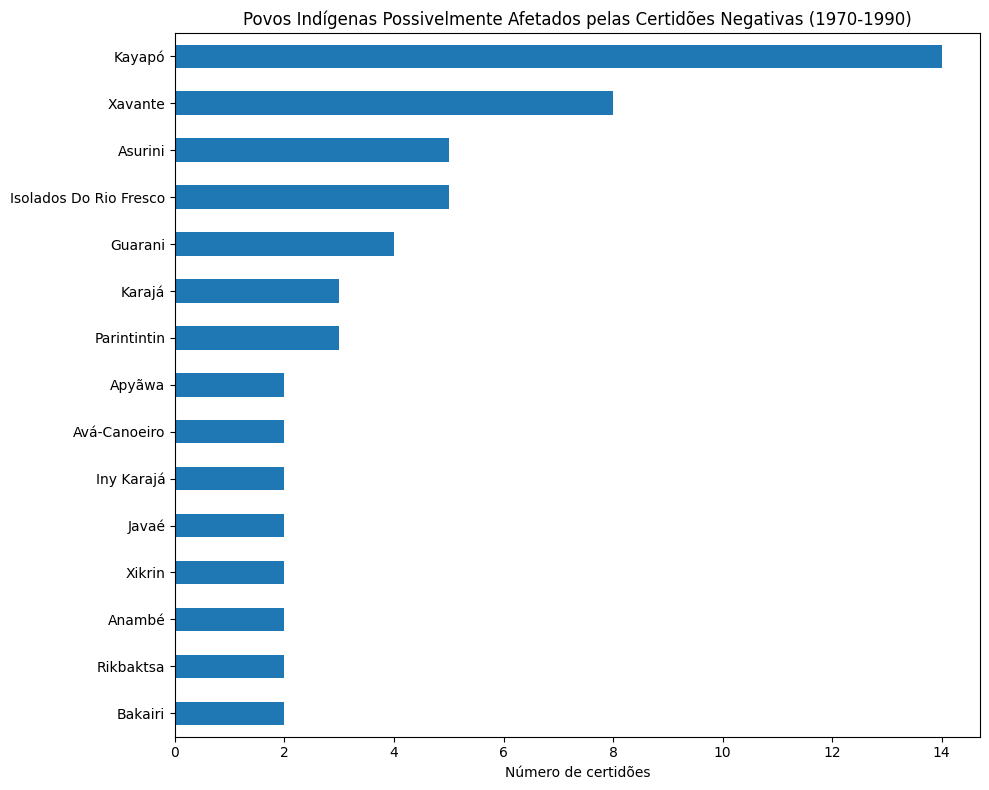

In [88]:
os.makedirs('../outputs/figures', exist_ok=True)

plt.figure(figsize=(10, 8))
contagem_afetados.head(15).plot(kind='barh')
plt.title('Povos Indígenas Possivelmente Afetados pelas Certidões Negativas (1970-1990)')
plt.xlabel('Número de certidões')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/02_povos_afetados.png', dpi=300)
plt.show()

In [89]:
print(df_rep['Povo ou terra indígena mencionado'].dropna().head(10))

0                                 Awá-Guajá
1                     TI Sepoti; Tenharim; 
2                        Muriru; Wapixana; 
3                                Potyguara;
4               Bororo; TI Tereza Cristina;
5      Tembé; Área Indígena Alto Rio Guamá;
6    Erikbaktsa; Área do Escondido; Apiaká;
7                       Erikbaktsa; Apiaká;
8                         Waimiri-Atroari; 
9                                    Waiãpi
Name: Povo ou terra indígena mencionado, dtype: str


In [90]:
col_rep = 'Povo ou terra indígena mencionado'

povos_rep = (df_rep[col_rep]
             .dropna()
             .str.split(';')
             .explode()
             .str.strip()
             .str.title())

povos_rep_unicos = set(povos_rep)
print(f"Total de entradas únicas nas reportagens: {len(povos_rep_unicos)}")
print(sorted(povos_rep_unicos))

Total de entradas únicas nas reportagens: 113
['', 'A.I. Do Alto Rio Guamá', 'Ai Guajahã', 'Ai Seruini/Marienê', 'Aldeia Do Banaal Do Acará-Miri Guamá', 'Aldeia Gomes Carneiro (Pi General Gomes Carneiro)', 'Alto Envira', 'Amanayé', 'Apiaká', 'Apurinã', 'Arara', 'Araras', 'Aripunã', 'Atroari', 'Awá-Guajá', 'Axinauá', 'Bororo', 'Camanaú', 'Campa', 'Catuquina', 'Caxarari', 'Caxinauá', 'Cinta-Larga', 'Colônia Teresa Cristina', 'Comissão Pró-Índio', 'Comunidade Indígena De Pari-Cachoeira', 'Culina', 'Diversos', 'Enauenê-Nauê', 'Erikbaktsa', 'Escondido', 'Gorotire', 'Iauanawa', 'Jamamadi', 'Jaminaua', 'Japutira', 'Japuíra', 'Karipuna', 'Katukina', 'Kayapó', 'Kulina', 'Manchineri', 'Marinaua', 'Mbyá-Guarani', 'Merure', 'Munxor', 'Muriru', 'Nambikuara', 'Nambikwara', 'Nambikwaras ("Nabikharas", No Texto)', 'Nambiquara', 'Nhambiquara', 'Nuquini', 'Não Consta', 'P.I. Areões', 'P.I. Couto Magalhães', 'P.I. Do Xingu', 'P.I. Laranjal No Baixo Madeira', 'P.I. Pedro Dantas', 'P.I. Xingu', 'Pacaa Nova

In [91]:
df_rep = pd.read_csv('../data/reportagens_certidoes_negativas_v2.csv')
print("Shape:", df_rep.shape)
print(list(df_rep.columns))

Shape: (105, 16)
['Nome do Jornal ou Revista', 'Estado da federação da publicação', 'Título do texto', 'Data da publicação', 'Nome do autor do texto', 'Povo indígena mencionado', 'TI Mencionada (entre parênteses o nome atual)', 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)', 'Nomes de empresas, fazendas ou indivíduos mencionados', 'Entrevista algum indígena?', 'Qual o nome do indígena entrevistado?', 'Há não-indígena entrevistado?', 'Nome do não-indígena entrevistado', 'Cargo ou profissão do não-indígena entrevistado', 'Se houver, evento mencionado (violência, crimes, etc)', 'Link da notícia']


In [92]:
col_rep_afetados = 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)'

povos_rep = (df_rep[col_rep_afetados]
             .dropna()
             .str.split(';')
             .explode()
             .str.strip()
             .str.title())

povos_rep_unicos = set(povos_rep)
print(f"Total de entradas únicas: {len(povos_rep_unicos)}")
print(sorted(povos_rep_unicos))

Total de entradas únicas: 66
['', 'Amanayé', 'Apiaká', 'Apurinã', 'Arara', 'Araweté', 'Ashaninka', 'Awa Guajá', 'Aweti', 'Bororo', 'Cinta-Larga', 'Enawenê-Nawê', 'Guarani', 'Ikpeng', 'Isolados Da Cabeceira Do Rio Camanaú', 'Isolados Do Igarapé Bom Jardim', 'Isolados Do Rio Jaminawá', 'Isolados Do Rio Tenente Marques', 'Isolados Do Riozinho Do Alto Envira', 'Jamamadi', "Ka'Apor", 'Kajkwakratxi (Tapayuna)', 'Kalapalo', 'Kamaiurá', 'Karipuna', 'Katukina', 'Kawaiwete (Kaiabi)', 'Kaxinawá', 'Kayapó', 'Khisêtjê', 'Kuikuro', 'Kulina', 'Manchineri', 'Matipu', 'Mehinako', 'Merure', 'Munxor', 'Mura', 'Muriru', 'Nahukwá', 'Nambikwara', 'Naruvotu', 'Nukini', 'Pacaa-Nova', 'Paresí', 'Potiguara', 'Puyanawa', 'Rikbaktsa', 'Tembé', 'Tenharim', 'Tikuna', 'Truaru', 'Trumai', 'Tukano', 'Tupiniquim', 'Turiwara', 'Uru-Eu-Wau-Wau', 'Waimiri-Atroari', 'Waiãpi', 'Wapixana', 'Wauja', 'Xavante', 'Yaminawá', 'Yawalapiti', 'Yudja', 'Zoró']


In [93]:
# Verificar inconsistências restantes
inconsistencias = ['Erikbaktsa', 'Potyguara']

for termo in inconsistencias:
    mask = df_rep[col_rep_afetados].dropna().str.contains(termo, case=False)
    resultado = df_rep[col_rep_afetados].dropna()[mask]
    if len(resultado) > 0:
        print(f"\n=== {termo} ===")
        print(resultado)

In [94]:
df_rep = pd.read_csv('../data/reportagens_certidoes_negativas_v2.csv')

col_rep_afetados = 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)'

povos_rep = (df_rep[col_rep_afetados]
             .dropna()
             .str.split(';')
             .explode()
             .str.strip()
             .str.title())

povos_rep_unicos = set(povos_rep)
print(f"Total de entradas únicas: {len(povos_rep_unicos)}")
print(sorted(povos_rep_unicos))

Total de entradas únicas: 66
['', 'Amanayé', 'Apiaká', 'Apurinã', 'Arara', 'Araweté', 'Ashaninka', 'Awa Guajá', 'Aweti', 'Bororo', 'Cinta-Larga', 'Enawenê-Nawê', 'Guarani', 'Ikpeng', 'Isolados Da Cabeceira Do Rio Camanaú', 'Isolados Do Igarapé Bom Jardim', 'Isolados Do Rio Jaminawá', 'Isolados Do Rio Tenente Marques', 'Isolados Do Riozinho Do Alto Envira', 'Jamamadi', "Ka'Apor", 'Kajkwakratxi (Tapayuna)', 'Kalapalo', 'Kamaiurá', 'Karipuna', 'Katukina', 'Kawaiwete (Kaiabi)', 'Kaxinawá', 'Kayapó', 'Khisêtjê', 'Kuikuro', 'Kulina', 'Manchineri', 'Matipu', 'Mehinako', 'Merure', 'Munxor', 'Mura', 'Muriru', 'Nahukwá', 'Nambikwara', 'Naruvotu', 'Nukini', 'Pacaa-Nova', 'Paresí', 'Potiguara', 'Puyanawa', 'Rikbaktsa', 'Tembé', 'Tenharim', 'Tikuna', 'Truaru', 'Trumai', 'Tukano', 'Tupiniquim', 'Turiwara', 'Uru-Eu-Wau-Wau', 'Waimiri-Atroari', 'Waiãpi', 'Wapixana', 'Wauja', 'Xavante', 'Yaminawá', 'Yawalapiti', 'Yudja', 'Zoró']


In [95]:
col_cert_afetados = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'
col_rep_afetados = 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)'

# Conjunto de povos de cada tabela
povos_cert = set(
    df_cert[col_cert_afetados]
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .str.title()
)

povos_rep = set(
    df_rep[col_rep_afetados]
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .str.title()
)

# Cruzamento
povos_em_ambos = povos_cert & povos_rep
povos_so_cert = povos_cert - povos_rep
povos_so_rep = povos_rep - povos_cert

print(f"Povos em AMBAS as tabelas: {len(povos_em_ambos)}")
print(sorted(povos_em_ambos))
print(f"\nPovos SÓ nas certidões: {len(povos_so_cert)}")
print(sorted(povos_so_cert))
print(f"\nPovos SÓ nas reportagens: {len(povos_so_rep)}")
print(sorted(povos_so_rep))

Povos em AMBAS as tabelas: 29
['', 'Arara', 'Araweté', 'Awa Guajá', 'Aweti', 'Guarani', 'Ikpeng', "Ka'Apor", 'Kajkwakratxi (Tapayuna)', 'Kalapalo', 'Kamaiurá', 'Kawaiwete (Kaiabi)', 'Kayapó', 'Khisêtjê', 'Kuikuro', 'Matipu', 'Mehinako', 'Nahukwá', 'Naruvotu', 'Rikbaktsa', 'Tembé', 'Tenharim', 'Trumai', 'Uru-Eu-Wau-Wau', 'Waimiri-Atroari', 'Wauja', 'Xavante', 'Yawalapiti', 'Yudja']

Povos SÓ nas certidões: 22
['Anambé', 'Apyãwa', 'Arawete', 'Asurini', 'Avá-Canoeiro', 'Awa-Guajá', 'Bakairi', 'Ikolen', 'Iny Karajá', 'Isolados Do Igarapé Preto', 'Isolados Do Rio Fresco', 'Isolados Kaidjuwa', 'Isolados Na Serra Da Previdência', 'Javaé', 'Kaingang', 'Karajá', 'Karo', 'Kayapó Araweté', 'Parakanã', 'Parintintin', 'Tapayuna', 'Xikrin']

Povos SÓ nas reportagens: 37
['Amanayé', 'Apiaká', 'Apurinã', 'Ashaninka', 'Bororo', 'Cinta-Larga', 'Enawenê-Nawê', 'Isolados Da Cabeceira Do Rio Camanaú', 'Isolados Do Igarapé Bom Jardim', 'Isolados Do Rio Jaminawá', 'Isolados Do Rio Tenente Marques', 'Isolados

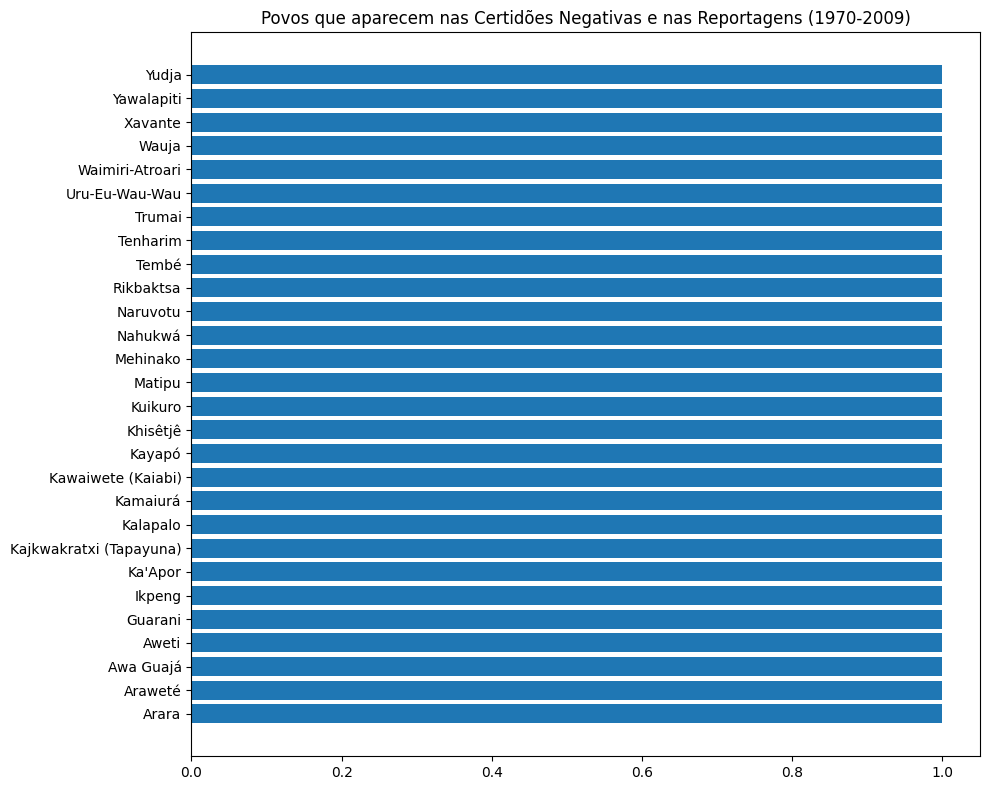

In [96]:
# Remover entrada vazia do conjunto
povos_em_ambos_limpo = sorted([p for p in povos_em_ambos if p != ''])

plt.figure(figsize=(10, 8))
plt.barh(range(len(povos_em_ambos_limpo)), 
         [1] * len(povos_em_ambos_limpo))
plt.yticks(range(len(povos_em_ambos_limpo)), povos_em_ambos_limpo)
plt.title('Povos que aparecem nas Certidões Negativas e nas Reportagens (1970-2009)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/03_povos_ambas_tabelas.png', dpi=300)
plt.show()

In [97]:
col_cert = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'
col_rep = 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)'

# Explodir certidões por povo
cert_exp = df_cert[['Nº do Processo', 'Data da Certidão', 'Observações', col_cert]].copy()
cert_exp[col_cert] = cert_exp[col_cert].str.split(';')
cert_exp = cert_exp.explode(col_cert)
cert_exp[col_cert] = cert_exp[col_cert].str.strip().str.title()

# Explodir reportagens por povo
rep_exp = df_rep[['Título do texto', 'Data da publicação', 'Se houver, evento mencionado (violência, crimes, etc)', 'Link da notícia', col_rep]].copy()
rep_exp[col_rep] = rep_exp[col_rep].str.split(';')
rep_exp = rep_exp.explode(col_rep)
rep_exp[col_rep] = rep_exp[col_rep].str.strip().str.title()

# Cruzamento
tabela = cert_exp.merge(rep_exp, left_on=col_cert, right_on=col_rep)

# Selecionar e renomear colunas
tabela = tabela[[col_cert, 'Nº do Processo', 'Data da Certidão', 
                 'Título do texto', 'Data da publicação',
                 'Observações', 'Se houver, evento mencionado (violência, crimes, etc)',
                 'Link da notícia']]

tabela.columns = ['Povo/TI', 'Número do Processo', 'Data da Certidão',
                  'Título da Reportagem', 'Data da Reportagem',
                  'Observações (certidão)', 'Evento Mencionado (rep.)',
                  'Link da Reportagem']

# Remover linhas com povo vazio
tabela = tabela[tabela['Povo/TI'] != '']

# Ordenar por povo e data da certidão
tabela = tabela.sort_values(['Povo/TI', 'Data da Certidão'])

print(f"Total de combinações: {len(tabela)}")
print(tabela.head(10))

Total de combinações: 719
       Povo/TI Número do Processo Data da Certidão  \
516      Arara  FUNAI/BSB/3919/78       22/01/1979   
517      Arara  FUNAI/BSB/3919/78       22/01/1979   
518      Arara  FUNAI/BSB/3919/78       22/01/1979   
519      Arara  FUNAI/BSB/3919/78       22/01/1979   
520      Arara  FUNAI/BSB/3919/78       22/01/1979   
510    Araweté  FUNAI/BSB/3375/80       16/06/1981   
78   Awa Guajá     1641/86-4ªSUER       06/02/1987   
79   Awa Guajá     1641/86-4ªSUER       06/02/1987   
80   Awa Guajá     1641/86-4ªSUER       06/02/1987   
29   Awa Guajá            0966/87       29/05/1987   

                                  Título da Reportagem Data da Reportagem  \
516                 A defesa de nova política indígena         14/07/1979   
517                         Valente, mas contraditório         01/10/1979   
518                                           COTRIJUÍ         01/01/1981   
519                          Os Arara, um povo em fuga         01/03/19

In [98]:
tabela.to_csv('../outputs/cruzamento_povos_certidoes_reportagens.csv', 
              index=False, 
              encoding='utf-8-sig')

print("Arquivo salvo em outputs/")

Arquivo salvo em outputs/


In [99]:
col_cert = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'
col_rep = 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)'

# Explodir certidões por povo
cert_exp = df_cert[['Nº do Processo', 'Data da Certidão', 'Observações', col_cert]].copy()
cert_exp[col_cert] = cert_exp[col_cert].str.split(';')
cert_exp = cert_exp.explode(col_cert)
cert_exp[col_cert] = cert_exp[col_cert].str.strip().str.title()
cert_exp = cert_exp[cert_exp[col_cert] != '']  # Remove vazios

# Explodir reportagens por povo
rep_exp = df_rep[['Título do texto', 'Data da publicação', 
                   'Se houver, evento mencionado (violência, crimes, etc)', 
                   'Link da notícia', col_rep]].copy()
rep_exp[col_rep] = rep_exp[col_rep].str.split(';')
rep_exp = rep_exp.explode(col_rep)
rep_exp[col_rep] = rep_exp[col_rep].str.strip().str.title()
rep_exp = rep_exp[rep_exp[col_rep] != '']  # Remove vazios

# Cruzamento
tabela = cert_exp.merge(rep_exp, left_on=col_cert, right_on=col_rep)

# Selecionar e renomear colunas
tabela = tabela[[col_cert, 'Nº do Processo', 'Data da Certidão',
                 'Título do texto', 'Data da publicação',
                 'Observações', 
                 'Se houver, evento mencionado (violência, crimes, etc)',
                 'Link da notícia']]

tabela.columns = ['Povo/TI', 'Número do Processo', 'Data da Certidão',
                  'Título da Reportagem', 'Data da Reportagem',
                  'Observações (certidão)', 'Evento Mencionado (rep.)',
                  'Link da Reportagem']

# Ordenar
tabela = tabela.sort_values(['Povo/TI', 'Data da Certidão']).reset_index(drop=True)

print(f"Total de combinações: {len(tabela)}")
print(f"Linhas vazias em Povo/TI: {tabela['Povo/TI'].isna().sum()}")
print(tabela.head(10).to_string())

Total de combinações: 719
Linhas vazias em Povo/TI: 527
     Povo/TI Número do Processo Data da Certidão                                                                                             Título da Reportagem Data da Reportagem                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      Observações (certidão)                                                                                                                                                                                

In [100]:
col_cert = 'Povos Possivelmente Afetados (Povos mencionadas + povos que habitam as TIs mencionadas)'
col_rep = 'Povos Possivelmente Afetados (Povos mencionados + povos que habitam as TIs mencionadas)'

# Explodir certidões por povo
cert_exp = df_cert[['Nº do Processo', 'Data da Certidão', 'Observações', col_cert]].copy()
cert_exp[col_cert] = cert_exp[col_cert].str.split(';')
cert_exp = cert_exp.explode(col_cert)
cert_exp[col_cert] = cert_exp[col_cert].str.strip().str.title()
cert_exp = cert_exp[cert_exp[col_cert].notna() & (cert_exp[col_cert] != '')]

# Explodir reportagens por povo
rep_exp = df_rep[['Título do texto', 'Data da publicação',
                   'Se houver, evento mencionado (violência, crimes, etc)',
                   'Link da notícia', col_rep]].copy()
rep_exp[col_rep] = rep_exp[col_rep].str.split(';')
rep_exp = rep_exp.explode(col_rep)
rep_exp[col_rep] = rep_exp[col_rep].str.strip().str.title()
rep_exp = rep_exp[rep_exp[col_rep].notna() & (rep_exp[col_rep] != '')]

# Cruzamento
tabela = cert_exp.merge(rep_exp, left_on=col_cert, right_on=col_rep)

# Selecionar e renomear colunas
tabela = tabela[[col_cert, 'Nº do Processo', 'Data da Certidão',
                 'Título do texto', 'Data da publicação',
                 'Observações',
                 'Se houver, evento mencionado (violência, crimes, etc)',
                 'Link da notícia']]

tabela.columns = ['Povo/TI', 'Número do Processo', 'Data da Certidão',
                  'Título da Reportagem', 'Data da Reportagem',
                  'Observações (certidão)', 'Evento Mencionado (rep.)',
                  'Link da Reportagem']

tabela = tabela.sort_values(['Povo/TI', 'Data da Certidão']).reset_index(drop=True)

print(f"Total de combinações: {len(tabela)}")
print(f"Linhas vazias em Povo/TI: {tabela['Povo/TI'].isna().sum()}")
print(tabela['Povo/TI'].value_counts())

Total de combinações: 192
Linhas vazias em Povo/TI: 0
Povo/TI
Xavante                    72
Kayapó                     28
Waimiri-Atroari            18
Ka'Apor                     8
Rikbaktsa                   8
Tembé                       8
Awa Guajá                   6
Arara                       5
Guarani                     4
Aweti                       2
Ikpeng                      2
Kajkwakratxi (Tapayuna)     2
Kalapalo                    2
Kamaiurá                    2
Kawaiwete (Kaiabi)          2
Khisêtjê                    2
Kuikuro                     2
Matipu                      2
Mehinako                    2
Nahukwá                     2
Naruvotu                    2
Trumai                      2
Wauja                       2
Yawalapiti                  2
Yudja                       2
Araweté                     1
Tenharim                    1
Uru-Eu-Wau-Wau              1
Name: count, dtype: int64


In [101]:
tabela.to_csv('../outputs/cruzamento_povos_certidoes_reportagens.csv', 
              index=False, 
              encoding='utf-8-sig')

print("Arquivo salvo em outputs/")
print(f"Total de linhas: {len(tabela)}")

Arquivo salvo em outputs/
Total de linhas: 192


In [102]:
# Agrupar reportagens por povo + certidão
def agrupa_reportagens(group):
    reportagens = []
    for _, row in group.iterrows():
        titulo = row['Título da Reportagem']
        data = row['Data da Reportagem']
        link = row['Link da Reportagem']
        evento = row['Evento Mencionado (rep.)']
        
        entrada = f"{titulo} ({data})"
        if pd.notna(evento):
            entrada += f" | Evento: {evento}"
        entrada += f" | Link: {link}"
        reportagens.append(entrada)
    
    return ' || '.join(reportagens)

tabela_agrupada = (tabela
    .groupby(['Povo/TI', 'Número do Processo', 'Data da Certidão', 'Observações (certidão)'])
    .apply(agrupa_reportagens)
    .reset_index()
    .rename(columns={0: 'Reportagens Relacionadas'})
)

tabela_agrupada = tabela_agrupada.sort_values(['Povo/TI', 'Data da Certidão']).reset_index(drop=True)

print(f"Total de linhas: {len(tabela_agrupada)}")
print(tabela_agrupada[['Povo/TI', 'Número do Processo', 'Data da Certidão', 'Reportagens Relacionadas']].head(10).to_string())

Total de linhas: 72
     Povo/TI Número do Processo Data da Certidão                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [103]:
tabela_agrupada.to_csv('../outputs/cruzamento_agrupado_por_certidao.csv',
                       index=False,
                       encoding='utf-8-sig')
print("Arquivo salvo em outputs/")
print(f"Total de linhas: {len(tabela_agrupada)}")

Arquivo salvo em outputs/
Total de linhas: 72


In [104]:
print(df_rep['Entrevista algum indígena?'].value_counts())

Entrevista algum indígena?
Não    96
Sim     7
Name: count, dtype: int64


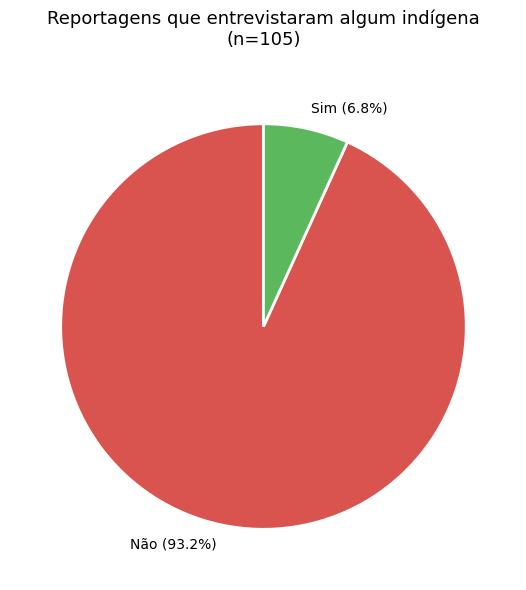

In [105]:
valores = df_rep['Entrevista algum indígena?'].value_counts()
total = valores.sum()
percentuais = (valores / total * 100).round(1)

plt.figure(figsize=(6, 6))
plt.pie(valores, 
        labels=[f'Não ({percentuais["Não"]}%)', f'Sim ({percentuais["Sim"]}%)'],
        colors=['#d9534f', '#5cb85c'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Reportagens que entrevistaram algum indígena\n(n=105)', 
          fontsize=13, pad=20)

plt.tight_layout()
plt.savefig('../outputs/figures/04_voz_indigena.png', dpi=300)
plt.show()